In [9]:
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

Based on the EDA, here's what we'll build:

```
Task 1: Regression  → predict total_magnetization
Task 2: Scoring     → rank materials by a composite "magnet score"
Task 3: Recommender → given element preferences → suggest best material
```

## Feature Engineering


In [3]:
df = pd.read_csv("./data/magnet_pm_filtered.csv").dropna(subset=["formation_energy", "energy_above_hull"])

--- Encode crystal system ---

In [4]:
le = LabelEncoder()
df["crystal_system_enc"] = le.fit_transform(df["crystal_system"])

--- Element presence flags for top magnetic elements ---

In [ ]:
top_elems = ["Fe", "Co", "Ni", "Mn", "Nd", "Sm", "Gd", "Eu", "O", "Li"]

def parse_elements(e):
    try:
        return ast.literal_eval(e)
    except:
        return []

df["elements_list"] = df["elements"].apply(parse_elements)

for elem in top_elems:
    df[f"has_{elem}"] = df["elements_list"].apply(lambda x: int(elem in x))

--- Log transform target (fixes skew) ---

In [7]:
df["log_magnetization"] = np.log1p(df["total_magnetization"])

--- Composite magnet score (higher = better permanent magnet) ---

In [8]:
df["magnet_score"] = (
    df["total_magnetization"] * 0.5 +
    df["magnetization_norm_vol"] * 500 +
    (0.1 - df["energy_above_hull"]).clip(0) * 100 +
    df["density"] * 0.5
)

df.to_csv("./data/magnet_features.csv", index=False)
print(df.shape)
print(df[["formula", "total_magnetization", "magnet_score"]].head(10))

(28472, 33)
          formula  total_magnetization  magnet_score
0         AcCeMg2             1.163836      9.345287
1           AcEu3            45.393970     96.903777
2          AcMgO3             1.000003     13.822634
3       Ag(AuF4)2             2.000000     17.667773
4  Ag14H8I4(OF2)5             3.998982      7.514654
5         Ag3IrO4             3.631366     12.908172
6        Ag3P3O10             4.000357     12.262683
7         Ag3RuO4            11.672043     25.867824
8         Ag3RuO4            19.891784     26.958964
9       Ag3Sb4F24             1.999734     14.038953


## Train Regression Model (Predict Magnetization)


In [10]:
feature_cols = [
    "nelements", "nsites", "volume", "density",
    "energy_above_hull", "formation_energy", "band_gap",
    "magnetization_norm_vol", "num_magnetic_sites",
    "crystal_system_enc",
    "has_Fe", "has_Co", "has_Ni", "has_Mn",
    "has_Nd", "has_Sm", "has_Gd", "has_Eu", "has_O", "has_Li"
]

X = df[feature_cols]
y = df["log_magnetization"]  # predicting log scale

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Random Forest

In [11]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print(f"Random Forest → MAE: {mae:.4f} | R²: {r2:.4f}")

Random Forest → MAE: 0.0110 | R²: 0.9992


Convert back from log scale for interpretability

In [12]:
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)
mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)
print(f"MAE in actual μB: {mae_actual:.2f}")

MAE in actual μB: 0.28


## Feature Importance


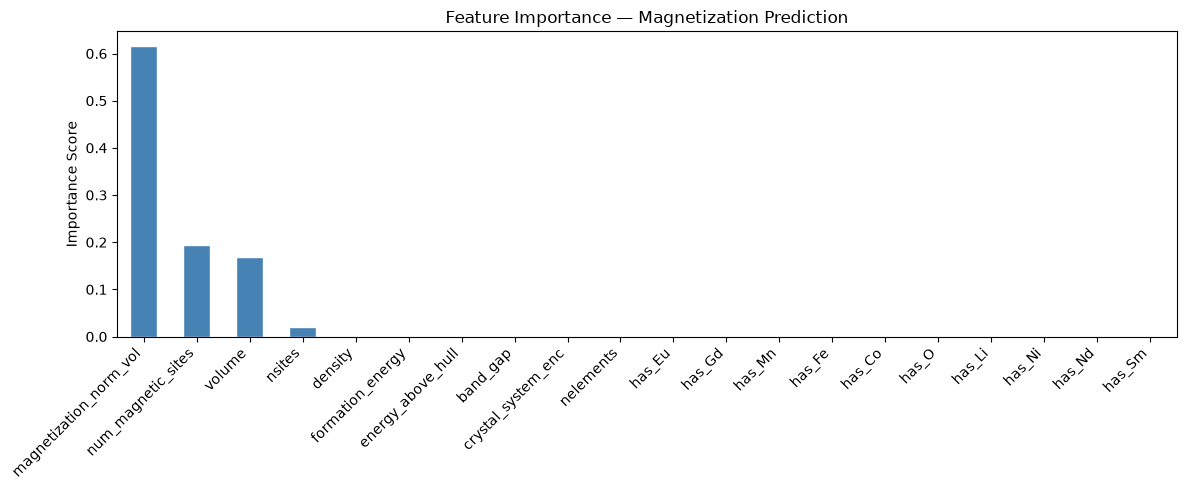

In [13]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importances.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Feature Importance — Magnetization Prediction")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

## Top Magnet Recommender


Rank all materials by composite score

In [14]:
top_recommended = df.nlargest(20, "magnet_score")[
    ["formula", "total_magnetization", "magnetization_norm_vol",
     "energy_above_hull", "density", "crystal_system", "magnet_score"]
].reset_index(drop=True)

top_recommended.index += 1
print("🏆 Top 20 Recommended Permanent Magnet Materials (by MagNet-IQ Score):\n")
print(top_recommended.to_string())

🏆 Top 20 Recommended Permanent Magnet Materials (by MagNet-IQ Score):

         formula  total_magnetization  magnetization_norm_vol  energy_above_hull    density crystal_system  magnet_score
1     Ba3Fe26O41           256.235535                0.154248           0.050177   5.037862      Hexagonal    212.742871
2     Zn(Fe2O3)4           228.072628                0.159946           0.049661   4.920101      Triclinic    201.503423
3          Mn2O3           256.002669                0.135580           0.078851   4.442863     Tetragonal    200.127822
4       Gd2Fe14C           171.819972                0.198450           0.035745   8.502761     Tetragonal    195.811859
5        Fe41O56           194.000000                0.179053           0.084820   4.882270       Trigonal    190.485611
6        LiFe5O8           200.001166                0.169255           0.098856   4.656037      Triclinic    187.070276
7       Eu16Sb11           223.998645                0.117525           0.000000  